```text
✅ 1. Project Setup & Imports
✅ 2. Load Config & LLM
✅ 3. Understand Iterative Workflows
✅ 4. Create Planner Node
✅ 5. Test Planner Node
✅ 6. Create Writer Node
✅ 7. Test Writer Node
✅ 8. Create Reviewer Node
✅ 9. Test Reviewer Node
✅ 10. Create StateGraph
✅ 11. Add Nodes
✅ 12. Create Loop Routing Function
✅ 13. Add Iterative Edges
✅ 14. Compile Graph
✅ 15. Execute Workflow
✅ 16. Observe Multiple Iterations
✅ 17. Visualize Workflow
✅ 18. Understand Self-Correction
✅ 19. Final Recap
```

In [1]:
import os
import sys
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project Root Added Successfully")
print(PROJECT_ROOT)

Project Root Added Successfully
c:\Users\Personal\Downloads\Learnyard-MLOps\GenAI-For-Dev-Course\19-LangGraph-Crash-Course


In [2]:
# ==========================================
# Load Config, LLM & LangGraph Components
# ==========================================

from src.utils.config_loader import load_config
from src.utils.model_loader import load_llm

from langgraph.graph import StateGraph
from langgraph.graph import START
from langgraph.graph import END

from src.states.state_schema import GraphState

config = load_config()
llm = load_llm()

print("Configuration Loaded Successfully")
print("LLM Loaded Successfully")
print(type(llm))

Configuration Loaded Successfully
LLM Loaded Successfully
<class 'langchain_openai.chat_models.base.ChatOpenAI'>


In [3]:
# ==========================================
# Understanding Iterative Workflows
# ==========================================

iterative_workflow = """
                START
                   |
                   v

                Planner
                   |
                   v

                 Writer
                   |
                   v

                Reviewer
                   |
                   v

                Continue?

                /      \\

              YES      NO

               |        |

               v        v

            Writer     END
"""

print(iterative_workflow)


                START
                   |
                   v

                Planner
                   |
                   v

                 Writer
                   |
                   v

                Reviewer
                   |
                   v

                Continue?

                /      \

              YES      NO

               |        |

               v        v

            Writer     END



In [4]:
# ==========================================
# Planner Node
# ==========================================

def planner_node(state: GraphState):
    print("\n--- Planner Node Executed ---")
    return {
        "research_notes":
        f"Create a concise explanation for: {state['user_query']}"
    }


print("Planner Node Created Successfully")

Planner Node Created Successfully


In [5]:
# ==========================================
# Test Planner Node
# ==========================================

result = planner_node(
    {
        "user_query": "What is LangGraph?"
    }
)

print(result)


--- Planner Node Executed ---
{'research_notes': 'Create a concise explanation for: What is LangGraph?'}


In [6]:
# ==========================================
# Writer Node
# ==========================================

def writer_node(state: GraphState):
    print("\n--- Writer Node Executed ---")
    feedback = state.get("review_feedback", "")

    prompt = f"""
    Topic:
    {state['user_query']}

    Instructions:
    {state['research_notes']}

    Reviewer Feedback:
    {feedback}

    Write a concise answer.
    """

    response = llm.invoke(prompt)
    return {"summary": response.content}

print("Writer Node Created Successfully")

Writer Node Created Successfully


In [7]:
# ==========================================
# Test Writer Node
# ==========================================

test_state = {
    "user_query": "What is LangGraph?",
    "research_notes":
    "Create a concise explanation for LangGraph."
}

result = writer_node(test_state)

print("\nDraft:\n")
print(result["summary"])


--- Writer Node Executed ---

Draft:

LangGraph is a framework designed to facilitate the development and deployment of language models and natural language processing (NLP) applications. It provides tools and infrastructure to efficiently manage, train, and integrate language models into various applications, enabling developers to leverage advanced NLP capabilities with ease.


In [ ]:
# ==========================================
# Reviewer Node
# ==========================================

def reviewer_node(state: GraphState):

    print("\n--- Reviewer Node Executed ---")
    current_iteration = state.get("iteration_count", 0)
    print(f"Current Iteration: {current_iteration}")

    next_iteration = current_iteration + 1

    if next_iteration < 2:

        return {
            "iteration_count": next_iteration,
            "review_feedback": "Needs more detail.",
            "next_step":
            "continue"
        }

    return {
        "iteration_count": next_iteration,
        "review_feedback": "Looks good.",
        "next_step":
        "end"
    }


print("Reviewer Node Created Successfully")

Reviewer Node Created Successfully


In [9]:
# ==========================================
# Test Reviewer Node
# ==========================================

result = reviewer_node(
    {
        "summary":
        "LangGraph is a workflow framework."
    }
)

print(result)


--- Reviewer Node Executed ---
Current Iteration: 0
{'iteration_count': 1, 'review_feedback': 'Needs more detail.', 'next_step': 'continue'}


In [10]:
# ==========================================
# Create StateGraph
# ==========================================

builder = StateGraph(GraphState)
print("StateGraph Created Successfully")

StateGraph Created Successfully


In [11]:
# ==========================================
# Add Nodes
# ==========================================
builder.add_node("planner", planner_node)
builder.add_node("writer", writer_node)
builder.add_node("reviewer", reviewer_node)

print("All Nodes Added Successfully")

All Nodes Added Successfully


In [12]:
# ==========================================
# Loop Routing Function
# ==========================================

def loop_decision(state: GraphState):
    return state["next_step"]

print("Loop Routing Function Created Successfully")

Loop Routing Function Created Successfully


In [13]:
# ==========================================
# Add Iterative Edges
# ==========================================
builder.add_edge(START, "planner")
builder.add_edge("planner", "writer")
builder.add_edge("writer", "reviewer")

builder.add_conditional_edges(
    "reviewer",
    loop_decision,
    {
        "continue": "writer",
        "end": END
    }
)

print("Iterative Workflow Created Successfully")

Iterative Workflow Created Successfully


In [14]:
# ==========================================
# Compile Graph
# ==========================================
graph = builder.compile()

print("Graph Compiled Successfully")
print(type(graph))

Graph Compiled Successfully
<class 'langgraph.graph.state.CompiledStateGraph'>


In [15]:
# ==========================================
# Execute Workflow
# ==========================================
result = graph.invoke(
    {
        "user_query":
        "What is LangGraph?"
    }
)
print("\nFINAL STATE\n")

for key, value in result.items():
    print(f"\n{key}:")
    print(value)


--- Planner Node Executed ---

--- Writer Node Executed ---

--- Reviewer Node Executed ---
Current Iteration: 0

--- Writer Node Executed ---

--- Reviewer Node Executed ---
Current Iteration: 1

FINAL STATE


user_query:
What is LangGraph?

research_notes:
Create a concise explanation for: What is LangGraph?

summary:
LangGraph is a framework designed to facilitate the development and deployment of language models and natural language processing (NLP) applications. It provides tools and infrastructure to manage complex workflows involving multiple language models, enabling seamless integration, scaling, and optimization of NLP tasks. LangGraph supports various use cases, including text generation, translation, sentiment analysis, and more, by offering a structured approach to handle data flow and model interactions efficiently.

next_step:
end

review_feedback:
Looks good.

iteration_count:
2


In [16]:
# ==========================================
# Observe Multiple Iterations
# ==========================================

print("""
Iteration Flow Observed

Iteration 1
-----------
Writer creates draft
Reviewer says:
Needs more detail

Iteration 2
-----------
Writer improves draft
Reviewer says:
Looks good

Workflow Ends
""")


Iteration Flow Observed

Iteration 1
-----------
Writer creates draft
Reviewer says:
Needs more detail

Iteration 2
-----------
Writer improves draft
Reviewer says:
Looks good

Workflow Ends



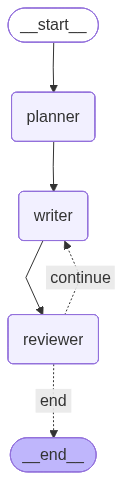

In [17]:
# ==========================================
# Visualize Iterative Workflow
# ==========================================

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))